# JXPaint Tutorial 4 — High resolution ($N_{\rm side}=4096$) and a 1.4 arcmin beam

The benchmark maps use $N_{\rm side}=1024$ and a 10 arcmin beam. JXPaint is not
tied to either: it paints at any $N_{\rm side}$, and any beam — we just need a
beam-convolved shape table for that beam. The cached table is 10 arcmin, so here
we **build a 1.4 arcmin table in Python** with `build_beamed_shape_table`
(beam2bl/bl2beam of the unbeamed Arnaud shape; it reproduces XGPaint's 10 arcmin
table to <0.1%). Then we paint at $N_{\rm side}=4096$ and check the physics by
comparing the **beam-deconvolved** power spectrum to the **unbeamed** hmfast
theory — the smaller beam pushes the comparison to much higher $\ell$.

In [1]:
import os, sys, time
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")  # share the GPU
sys.path.insert(0, os.path.join("..", "src"))   # run from tutorials/
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import jax
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## 1. Build a 1.4 arcmin beam-convolved shape table

This convolves the projected GNFW shape with a 1.4 arcmin Gaussian, per
$\theta_{500}$ column (takes a couple of minutes; it's a one-time build).

In [2]:
from jxpaint.profiles.shape_table import build_beamed_shape_table
t0 = time.time()
st14 = build_beamed_shape_table(1.4)          # 1.4 arcmin beam
print(f"built 1.4' shape table in {time.time()-t0:.0f} s")

built 1.4' shape table in 157 s


## 2. Paint the catalogue at $N_{\rm side}=4096$

We pass `fwhm_arcmin=1.4` so the per-halo paint radius uses the correct beam
floor.  At $N_{\rm side}=4096$ the pixels are ~0.85 arcmin, well sampled by the
1.4 arcmin beam.

In [3]:
import pandas as pd
from jxpaint.painting.gpu_native import paint_catalogue_gpu_native
CAT = "/rds/rds-lxu/tsz_project/tsz_catalogue_benchmark/catalogue_bench_snr_0.csv"
df = pd.read_csv(CAT)
z, M, lon, lat, y0 = (df.z.values, df.M.values, df.lon.values, df.lat.values, df.y0_true.values)
t0 = time.time()
m = paint_catalogue_gpu_native(z, M, lon, lat, y0, st14, nside=4096, fwhm_arcmin=1.4,
                               chunk=20_000_000, e_per_halo=45, n_per_halo=820)
print(f"painted {len(df)} halos at nside=4096 in {time.time()-t0:.1f} s")
print(f"map: {m.size:,} pixels, nonzero={np.count_nonzero(m):,}, max={m.max():.3e}")

painted 307170 halos at nside=4096 in 5.2 s


map: 201,326,592 pixels, nonzero=119,247,234, max=3.096e-04


## 3. Visualise — sharper clusters

A gnomonic zoom on the most massive cluster: with the 1.4 arcmin beam the cluster
is far sharper than the 10 arcmin maps of Tutorial 1.

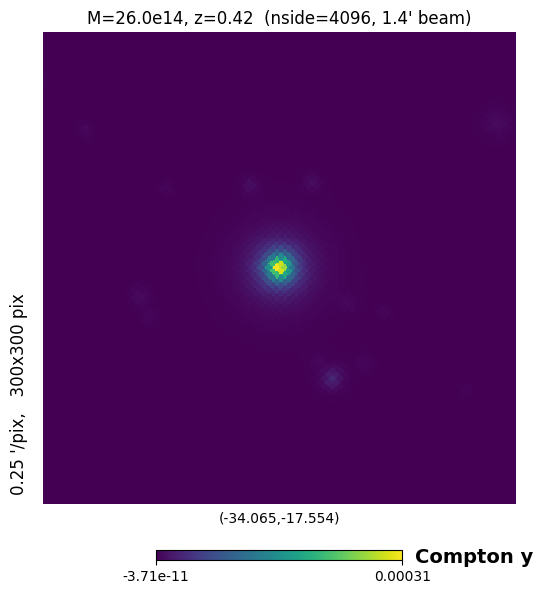

In [4]:
import healpy as hp
i_big = int(np.argmax(M))
ra = np.remainder(lon[i_big] + np.pi, 2*np.pi) - np.pi
dec = lat[i_big] - np.pi/2
hp.gnomview(m, rot=(np.degrees(ra), np.degrees(dec)), reso=0.25, xsize=300,
            title=f"M={M[i_big]:.1f}e14, z={z[i_big]:.2f}  (nside=4096, 1.4' beam)",
            unit="Compton y")
plt.show()

## 4. Power spectrum: beam-deconvolved data vs unbeamed theory

We compute the map $C_\ell^{yy}$, **divide out the 1.4 arcmin beam**
($C_\ell/b_\ell^2$) to get the unbeamed data spectrum, and compare to the
**unbeamed** hmfast 1-halo theory (standard Arnaud GNFW, imported directly,
computed to $\ell=5000$). The smaller beam keeps signal to much higher $\ell$
than the 10 arcmin case.

beam-deconvolved data / hmfast 1-halo (Arnaud), l=300-4000 mean = 0.83


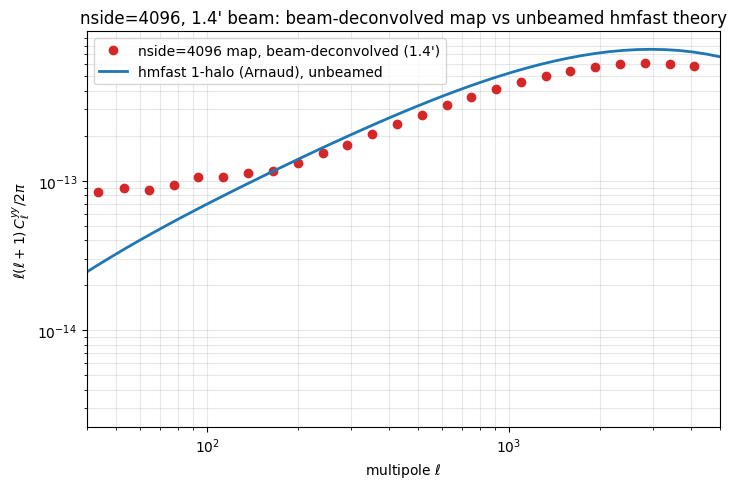

In [5]:
import sys
sys.path.insert(0, "/scratch/scratch-lxu/agent_dev/auto_research_agent/hmfast/src")
import jax.numpy as jnp
from hmfast.cosmology import Cosmology
from hmfast.halos.halo_model import HaloModel
from hmfast.halos.mass_definition import MassDefinition
from hmfast.halos.concentration import D08Concentration
from hmfast.halos.profiles.pressure import GNFWPressureProfile
from hmfast.tracers.tsz import tSZTracer

cosmo = Cosmology(emulator_set="lcdm:v1", H0=67.66, omega_b=0.02242, omega_cdm=0.1193)
hm = HaloModel(cosmology=cosmo, mass_definition=MassDefinition(delta=500, reference="critical"),
               concentration=D08Concentration(), convert_masses=True, hm_consistency=False)
tracer = tSZTracer(profile=GNFWPressureProfile(P0=8.130, c500=1.156, alpha=1.0620,
                                               beta=5.4807, gamma=0.3292, B=1.41))
m_th = jnp.asarray(np.logspace(14.0, 16.0, 80))
z_th = jnp.asarray(np.logspace(np.log10(0.005), np.log10(2.81), 160))
ell_th = np.unique(np.logspace(1, np.log10(5000), 60).astype(int)).astype(float)
cl_th = np.asarray(hm.cl_1h(tracer, None, jnp.asarray(ell_th), m_th, z_th))   # unbeamed, to l=5000

lmax = 5500
cl = hp.anafast(m, lmax=lmax); ell = np.arange(lmax+1)
bl = hp.gauss_beam(np.radians(1.4/60.0), lmax=lmax)
cl_dec = cl / bl**2
edges = np.unique(np.logspace(np.log10(40), np.log10(4500), 26).astype(int))
lb = 0.5*(edges[1:]+edges[:-1])
clb_dec = np.array([cl_dec[edges[i]:edges[i+1]].mean() for i in range(len(edges)-1)])
r = clb_dec / np.interp(lb, ell_th, cl_th)
print(f"beam-deconvolved data / hmfast 1-halo (Arnaud), l=300-4000 mean = "
      f"{r[(lb>300)&(lb<4000)].mean():.2f}")

Dl = lambda L, c: L*(L+1)*c/(2*np.pi)
plt.figure(figsize=(7.4, 5))
plt.loglog(lb, Dl(lb, clb_dec), "o", color="C3", label="nside=4096 map, beam-deconvolved (1.4')")
plt.loglog(ell_th, Dl(ell_th, cl_th), "-", color="C0", lw=2, label="hmfast 1-halo (Arnaud), unbeamed")
plt.xlabel(r"multipole $\ell$"); plt.ylabel(r"$\ell(\ell+1)\,C_\ell^{yy}/2\pi$")
plt.title("nside=4096, 1.4' beam: beam-deconvolved map vs unbeamed hmfast theory")
plt.xlim(40, 5000); plt.legend(); plt.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

**Result.** With a 1.4 arcmin beam at $N_{\rm side}=4096$, the beam-deconvolved
map matches the unbeamed hmfast 1-halo theory with the **same flat ratio
$\approx0.8$** as Tutorial 1's 10 arcmin map — but now out to $\ell\sim4000$
instead of $\ell\sim1500$, because the smaller beam preserves small-scale power.
The constant 0.8 is again the catalogue's $\sim0.8\times$ Tinker abundance plus
$y_0$ scatter (pure amplitude). This shows JXPaint paints correctly at high
resolution and any beam: `build_beamed_shape_table(fwhm)` makes the beam a free
parameter, and the painter takes `nside` and `fwhm_arcmin` directly.